In [17]:
import zipfile
with zipfile.ZipFile('/content/archive.zip','r') as z:
  z.extractall('/content/')
  print(z.namelist())

['Advertising.csv']


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/Advertising.csv')
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [19]:
print("Shape:",df.shape)
print("\nColumns:",df.columns.tolist())
print("\nMissing values:\n",df.isnull().sum())
print("\nDescribe:\n",df.describe())

Shape: (200, 5)

Columns: ['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']

Missing values:
 Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

Describe:
        Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400000   49.600000  114.000000   27.000000


In [20]:
df=df.drop(columns=['Unnamed: 0'])
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


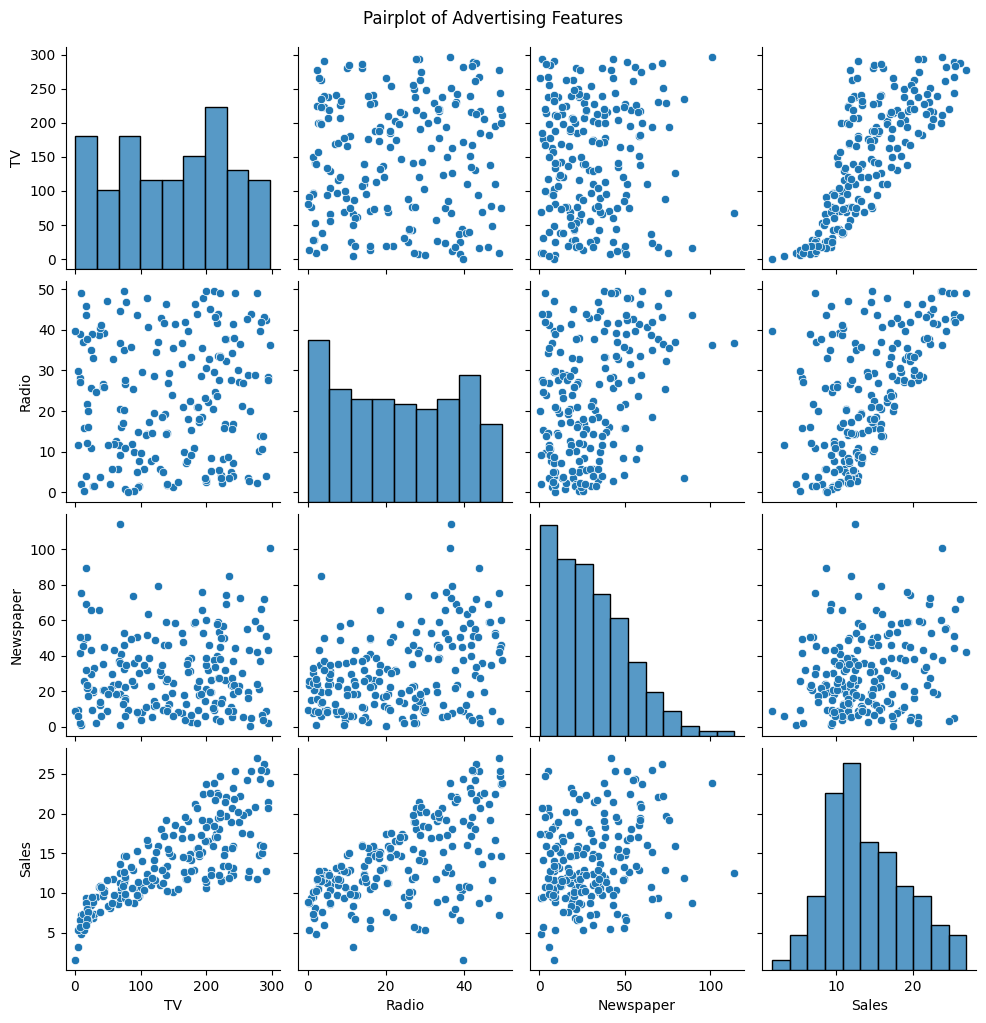

In [21]:
sns.pairplot(df)
plt.suptitle("Pairplot of Advertising Features",y=1.02)
plt.show()

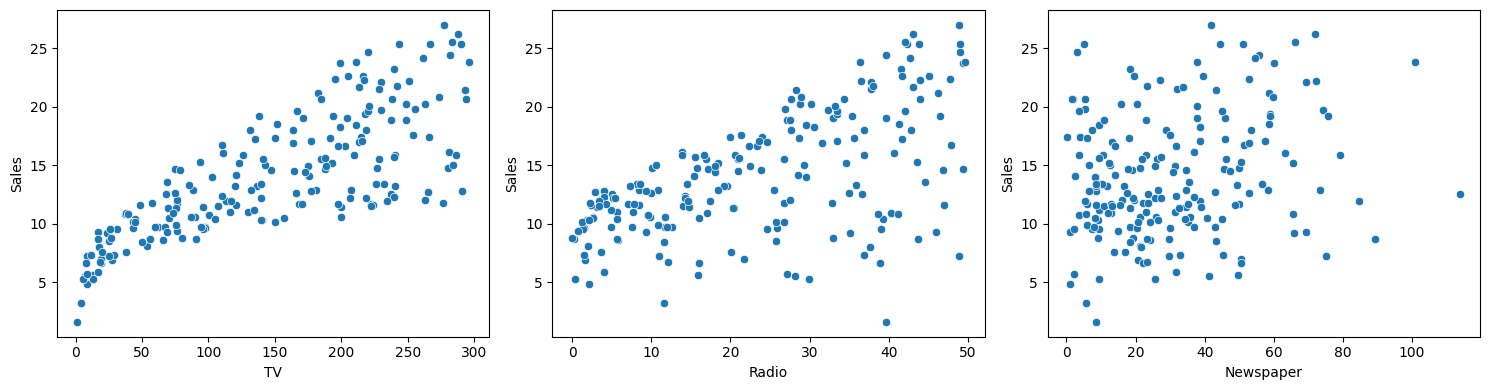

In [22]:
fig, axes=plt.subplots(1,3, figsize=(15,4))
sns.scatterplot(data=df,x='TV',y='Sales',ax=axes[0])
sns.scatterplot(data=df,x='Radio',y='Sales',ax=axes[1])
sns.scatterplot(data=df,x='Newspaper',y='Sales',ax=axes[2])
plt.tight_layout()
plt.show()

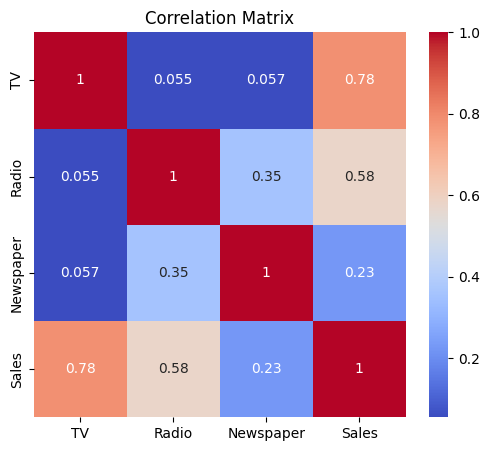

In [23]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
X=df[['TV', 'Radio','Newspaper']]
y=df['Sales']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Train:",X_train.shape,"Test:",X_test.shape)

Train: (160, 3) Test: (40, 3)


In [25]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)
pred_lr=lr.predict(X_test)
print("Coefficients:",dict(zip(X.columns,lr.coef_)))
print("Intercept:",lr.intercept_)

Coefficients: {'TV': np.float64(0.044729517468716326), 'Radio': np.float64(0.18919505423437652), 'Newspaper': np.float64(0.0027611143413671935)}
Intercept: 2.979067338122629


In [26]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
pred_rf=rf.predict(X_test)
print("Random Forest trained.")


Random Forest trained.


In [27]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
for name,pred in[('Linear Regression',pred_lr),('Random Forest',pred_rf)]:
  mae=mean_absolute_error(y_test,pred)
  rmse=mean_squared_error(y_test,pred)**0.5
  r2=r2_score(y_test,pred)
  print(f"=== {name} ===")
  print(f"MAE:{mae:.3f},RMSE:{rmse:.3f},R2:{r2:.3f}\n")


=== Linear Regression ===
MAE:1.461,RMSE:1.782,R2:0.899

=== Random Forest ===
MAE:0.620,RMSE:0.769,R2:0.981



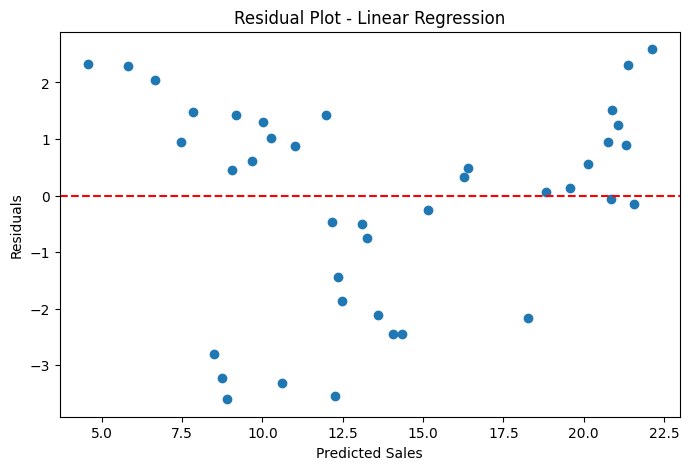

In [28]:
residuals=y_test-pred_lr
plt.figure(figsize=(8,5))
plt.scatter(pred_lr,residuals)
plt.axhline(y=0,color='r',linestyle='--')
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")
plt.show()

## Conclusion
Random Forest significantly outperformed Linear Regression on this dataset
(R2 of 0.981 vs 0.899, and roughly half the error on both MAE and RMSE).
This suggests the true relationship between advertising spend and sales is
not purely linear — likely showing diminishing returns, especially visible
in the TV vs Sales scatter plot earlier.

Based on the Linear Regression coefficients, TV has by far the strongest
positive impact on Sales, followed by Radio, with Newspaper contributing
the least. This aligns with the correlation analysis (TV: 0.78, Radio: 0.58,
Newspaper: 0.23).

Random Forest is the recommended model for this prediction task given its
superior performance.